# TD4 — Feature engineering EEG pour l'estimation de la charge cognitive

## Contexte

Ce TD s'inscrit dans le projet fil rouge basé sur le papier :

**Multimodal Brain-Computer Interface for In-Vehicle Driver Cognitive Load Measurement: Dataset and Baselines**.

Le papier introduit le dataset **CL-Drive**, dans lequel des signaux EEG, ECG, EDA et Gaze sont enregistrés pendant une tâche de conduite simulée. Les scores de charge cognitive sont collectés toutes les **10 secondes**. Après prétraitement, les signaux sont segmentés en fenêtres de 10 s, puis transformés en caractéristiques numériques pour entraîner des modèles de classification.

Dans ce TD, on se concentre uniquement sur les **features EEG**.

---

## Objectifs pédagogiques

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi on transforme un signal EEG en vecteur de caractéristiques ;
2. distinguer les features temporelles, fréquentielles et non linéaires ;
3. expliquer le principe de la densité spectrale de puissance, ou PSD ;
4. calculer des puissances par bande EEG ;
5. interpréter l'entropie spectrale ;
6. expliquer les paramètres de Hjorth ;
7. comprendre le principe de la complexité de Lempel-Ziv ;
8. comprendre l'idée de la dimension fractale de Higuchi ;
9. structurer une fonction complète d'extraction de features EEG ;
10. préparer une matrice de features pour la classification.

---

## Features EEG ciblées

Le papier regroupe les features EEG suivantes :

| Famille | Features |
|---|---|
| PSD | puissance absolue, moyenne, maximale, minimale et médiane |
| Entropie spectrale | entropie calculée à partir de la PSD normalisée |
| Hjorth | mobility et complexity |
| Lempel-Ziv | complexité d'une séquence binarisée |
| Higuchi | dimension fractale |
| Statistiques temporelles | moyenne, minimum, maximum, médiane, variance, écart-type |

Dans ce TD, on adopte une version complète :

- PSD calculée dans les cinq bandes EEG : delta, theta, alpha, beta, gamma ;
- entropie spectrale calculée dans les cinq bandes ;
- features non linéaires calculées sur le segment temporel ;
- statistiques temporelles calculées sur le segment.

On obtient donc :

$$
5 \text{ bandes} \times 5 \text{ descripteurs PSD} = 25
$$

$$
5 \text{ entropies spectrales} = 5
$$

$$
2 \text{ Hjorth} + 1 \text{ Lempel-Ziv} + 1 \text{ Higuchi} + 6 \text{ statistiques} = 10
$$

Soit au total :

$$
25 + 5 + 10 = 40 \text{ features par canal EEG}
$$

## Questions de compréhension

### Question 1

Pourquoi ne donne-t-on pas directement le signal EEG brut à un classifieur classique comme LDA, SVM ou Random Forest ?

### Réponse

Un signal EEG brut sur une fenêtre de 10 secondes à 256 Hz représente **2560 valeurs consécutives**. Donner ce vecteur directement à un classifieur pose trois problèmes :

1. **Fléau de la dimensionnalité** : LDA, SVM et Random Forest ne sont pas conçus pour traiter des entrées de 2560 dimensions. Avec peu d'exemples d'entraînement face à autant de dimensions, les modèles sur-apprennent facilement et généralisent mal.

2. **Redondance** : des échantillons consécutifs très proches en temps contiennent beaucoup d'information répétée (le signal ne change pas brusquement entre deux mesures séparées de 4 ms). Le signal brut n'est pas compressé de façon utile pour la classification.

3. **Manque de sens** : la valeur instantanée d'un canal EEG à un instant donné n'est pas interprétable seule. Ce qui compte, c'est la répartition de l'énergie sur les bandes de fréquence, la complexité du signal, etc.


### Question 2

Pourquoi les features fréquentielles sont-elles particulièrement importantes en EEG ?

### Réponse

L'EEG est naturellement organisé en **bandes de fréquence** qui correspondent à des processus cognitifs distincts et bien documentés en neurosciences :

- La bande **theta (4–8 Hz)** augmente typiquement lors d'un effort mental soutenu et de la charge en mémoire de travail.
- La bande **alpha (8–12 Hz)** diminue lors d'un effort cognitif élevé (désynchronisation alpha = mobilisation de ressources cognitives).
- La bande **beta (12–30 Hz)** est associée à l'attention active et au raisonnement.

Ces relations entre fréquences et états cognitifs en font des **indicateurs directs de la charge cognitive**. De plus, les features fréquentielles (calculées sur une fenêtre de 10 s entière) sont **robustes aux artefacts ponctuels** : un clignement d'œil affecte quelques dizaines d'échantillons mais ne décale pas significativement la PSD calculée sur 2560 points.

En résumé : les features fréquentielles capturent l'état mental du conducteur de façon synthétique, stable et physiologiquement interprétable.

### Question 3

Pourquoi faut-il calculer les features séparément sur chaque canal EEG ?

### Réponse

Les quatre canaux du Muse S mesurent des **régions cérébrales différentes** :

- **AF7 / AF8** (préfrontal gauche/droit) : zones associées aux fonctions exécutives, à la prise de décision et à l'attention.
- **TP9 / TP10** (temporo-pariétal gauche/droit) : zones associées à la perception, à l'intégration sensorielle et à la conscience spatiale.

La charge cognitive n'affecte pas ces régions de la même façon ni avec la même intensité. Un calcul sur un seul canal ou sur la moyenne de tous les canaux perdrait cette **information spatiale** (topographique).

En calculant les 40 features séparément sur chaque canal, puis en concaténant les résultats, on obtient **160 features par segment** qui préservent la différenciation régionale. Le modèle peut alors apprendre quels canaux et quelles bandes sont les plus discriminants pour la charge cognitive — ce qu'une moyenne globale ne permettrait pas.

## 1. Bandes fréquentielles EEG

Les signaux EEG sont souvent analysés par bandes de fréquence.

| Bande | Intervalle utilisé dans ce TD | Interprétation générale |
|---|---:|---|
| Delta | 0.5–4 Hz | activité lente |
| Theta | 4–8 Hz | attention, mémoire de travail, somnolence selon contexte |
| Alpha | 8–12 Hz | relaxation, inhibition, yeux fermés |
| Beta | 12–30 Hz | activité mentale, attention, activité motrice |
| Gamma | 30–75 Hz | activité rapide, intégration, mais sensible aux artefacts musculaires |

Dans le papier, la bande gamma va jusqu'à 75 Hz. 

### Question 4

Pourquoi peut-on limiter la bande gamma à 45 Hz dans certaines implémentations ?

### Réponse

Les **artefacts musculaires (EMG)** commencent à contaminer le signal EEG à partir d'environ 40–50 Hz. Les muscles du visage, de la mâchoire et du cou génèrent une activité électrique haute fréquence qui se superpose au signal cérébral. Pour des dispositifs grand public avec des électrodes sèches (comme le Muse S), le rapport signal/bruit au-dessus de 45 Hz est souvent médiocre.

Limiter gamma à 45 Hz est donc une décision **conservatrice** qui réduit le risque d'inclure des artefacts musculaires dans les features.

Le papier CL-Drive va jusqu'à **75 Hz** car :
- les auteurs appliquent un prétraitement (filtre passe-bande 0.4–75 Hz) qui conserve cette bande ;
- ils jugent que la bande gamma jusqu'à 75 Hz apporte une information discriminante pour la charge cognitive, même avec des électrodes sèches.

Les deux choix (45 Hz ou 75 Hz) sont valides selon le dispositif et la qualité du signal.

## 2. Méthodologie d'implémentation 

Dans ce TD, l'objectif est de comprendre puis implémenter les fonctions essentielles.

Pour chaque fonction, vous aurez :

- une explication théorique ;
- l'algorithme ;
- les fonctions Python recommandées ;
- les paramètres importants ;
- des questions de vérification.

Les bibliothèques utiles sont :

| Objectif | Bibliothèque | Fonctions utiles |
|---|---|---|
| Tableaux numériques | NumPy | `np.array`, `np.mean`, `np.var`, `np.diff`, `np.median` |
| Données tabulaires | pandas | `pd.DataFrame`, `pd.read_csv`, `to_csv` |
| PSD | scipy.signal | `welch` |
| Entropie | scipy.stats | `entropy` |
| Visualisation | matplotlib | `plt.plot`, `plt.semilogy`, `plt.bar` |

### Travail à réaliser

Vous devez construire progressivement les fonctions suivantes :

1. `compute_psd_band_features(signal, fs)` ;
2. `compute_spectral_entropy_bands(signal, fs)` ;
3. `compute_hjorth(signal)` ;
4. `lempel_ziv_complexity(signal)` ;
5. `higuchi_fd(signal, kmax=10)` ;
6. `compute_raw_features(signal)` ;
7. `extract_eeg_features(signal, fs)` ;
8. une boucle permettant d'extraire les features sur des fenêtres de 10 secondes.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import entropy

FS = 256
WINDOW_SEC = 10
WINDOW_SAMPLES = FS * WINDOW_SEC

EEG_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 31),
    "gamma": (31, 75),
}

print("Nombre d'échantillons par fenêtre :", WINDOW_SAMPLES)
print("Bandes EEG :", EEG_BANDS)

Nombre d'échantillons par fenêtre : 2560
Bandes EEG : {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 31), 'gamma': (31, 75)}


## 3. Exemples pédagogiques sur signaux connus

Avant d'appliquer les features à l'EEG réel, on commence par des signaux connus.

On va comparer :

1. une sinusoïde à 2 Hz, principalement dans la bande delta ;
2. une sinusoïde à 10 Hz, principalement dans la bande alpha ;
3. une sinusoïde à 20 Hz, principalement dans la bande beta ;
4. un bruit blanc, dont l'énergie est plus répartie ;
5. un mélange de plusieurs composantes.

### Objectif pédagogique

Vérifier que les features donnent des résultats cohérents :

- une sinusoïde pure doit avoir une PSD concentrée ;
- le bruit doit avoir une entropie spectrale plus élevée ;
- une sinusoïde alpha doit avoir une puissance alpha dominante.

In [2]:
# Cellule d'aide : génération de signaux synthétiques pour les tests pédagogiques.
# Vous pouvez l'utiliser pour tester vos futures fonctions de features.

def generate_synthetic_signals(fs=FS, duration=10, random_state=0):
    rng = np.random.default_rng(random_state)
    t = np.arange(0, duration, 1/fs)
    signals = {
        "delta_2Hz": np.sin(2*np.pi*2*t),
        "alpha_10Hz": np.sin(2*np.pi*10*t),
        "beta_20Hz": np.sin(2*np.pi*20*t),
        "white_noise": rng.normal(0, 1, size=len(t)),
        "mixed": 0.8*np.sin(2*np.pi*6*t) + 0.5*np.sin(2*np.pi*10*t) + 0.2*rng.normal(0, 1, size=len(t)),
    }
    return t, signals

t, synthetic_signals = generate_synthetic_signals()

## 4. Feature PSD : densité spectrale de puissance

### Principe théorique

La **PSD**, ou densité spectrale de puissance, indique comment la puissance du signal est répartie selon la fréquence.

Pour un segment EEG $x[n]$, on estime la PSD avec la méthode de Welch. L'idée est de :

1. découper le signal en sous-fenêtres ;
2. calculer un spectre sur chaque sous-fenêtre ;
3. moyenner les spectres pour obtenir une estimation plus stable.

En Python, on utilise généralement :

```python
freqs, psd = scipy.signal.welch(signal, fs=fs, nperseg=...)
```

### Paramètres recommandés

- `fs=256` pour CL-Drive ;
- `nperseg=fs*2` pour une fenêtre Welch de 2 secondes ;
- si le segment est court, prendre `nperseg=min(len(signal), fs*2)` ;
- sélectionner ensuite les fréquences appartenant à une bande donnée à l’aide d’un masque booléen (utiliser le vecteur `freqs` retourné `scipy.signal.welch`).

### Features PSD pour chaque bande

Pour chaque bande EEG, calculer :

1. puissance absolue : somme de la PSD dans la bande ;
2. puissance moyenne ;
3. puissance maximale ;
4. puissance minimale ;
5. puissance médiane.

### Algorithme

1. calculer `freqs, psd` avec Welch ;

Pour chaque bande $[f_{min}, f_{max}]$ :

   
2. sélectionner les indices tels que $f_{min} \le f < f_{max}$ ;
3. extraire `band_psd` ;
4. calculer `sum`, `mean`, `max`, `min`, `median` ;
5. stocker les résultats dans un dictionnaire.

### Questions

1. Quelle bande doit dominer pour un signal sinusoïdal à 10 Hz ?
2. Pourquoi la PSD est-elle plus stable avec Welch qu'avec un simple spectre FFT ?
3. Que se passe-t-il si la bande sélectionnée ne contient aucune fréquence ?

### Réponses

**1.** La bande **alpha (8–12 Hz)** doit dominer, car la sinusoïde à 10 Hz tombe exactement dans cet intervalle. Sur la PSD, on doit voir un pic très étroit à 10 Hz, et la puissance absolue de la bande alpha sera bien supérieure à toutes les autres bandes.

**2.** Une FFT directe produit un spectre **bruité et instable** : chaque bin fréquentiel est estimé à partir d'une seule observation, avec une grande variance. Welch **découpe le signal en sous-fenêtres qui se chevauchent**, calcule un spectre sur chacune, puis **les moyenne**. La variance de l'estimation diminue proportionnellement au nombre de sous-fenêtres utilisées, au prix d'une résolution fréquentielle un peu plus grossière (`Δf = fs / nperseg`). Pour un signal EEG, ce compromis est avantageux car on veut une estimation stable de la puissance par bande, pas une résolution fréquentielle extrême.

**3.** Si aucune fréquence du vecteur `freqs` (retourné par Welch) ne tombe dans la bande, le masque booléen ne sélectionne rien et `band_psd` est un tableau vide. Les calculs de `sum`, `mean`, `max`, `min` et `median` sur un tableau vide produiraient des erreurs ou des `NaN`. Il faut donc **vérifier `if len(band_psd) == 0`** et retourner `0.0` par convention, en s'assurant que la résolution fréquentielle (`nperseg`) est suffisante pour qu'au moins un bin tombe dans chaque bande.

=== Test compute_psd_band_features ===

delta_2Hz       → bande dominante : delta     (abs=1.0000)
alpha_10Hz      → bande dominante : alpha     (abs=1.0000)
beta_20Hz       → bande dominante : beta      (abs=1.0000)
white_noise     → bande dominante : gamma     (abs=0.7051)
mixed           → bande dominante : theta     (abs=0.6460)

Nombre de features PSD : 25


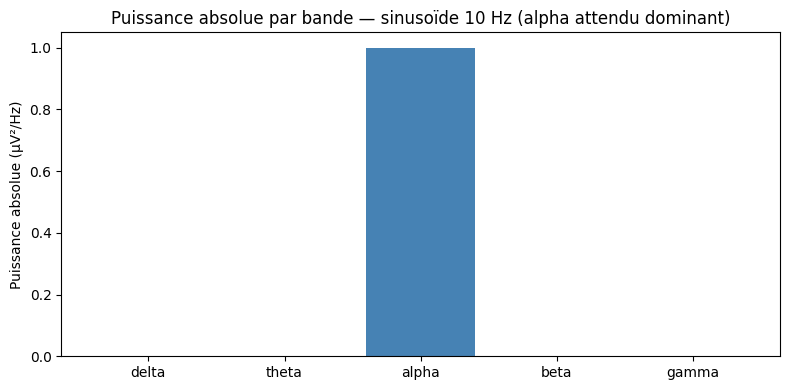

In [3]:
import numpy as np
from scipy.signal import welch


def compute_welch_psd(signal, fs=FS):
    """
    Calcule la PSD d'un signal 1D avec la méthode de Welch.

    Paramètres
    ----------
    signal : tableau 1D (n_samples,)
    fs     : fréquence d'échantillonnage en Hz

    Retourne
    --------
    freqs : tableau des fréquences (Hz)
    psd   : tableau de la densité spectrale de puissance (µV²/Hz)
    """
    # nperseg = taille de chaque sous-fenêtre Welch
    # On prend au plus 2 secondes de signal, sans dépasser la longueur totale
    nperseg = min(len(signal), fs * 2)
    freqs, psd = welch(signal, fs=fs, nperseg=nperseg)
    return freqs, psd


def compute_psd_band_features(signal, fs=FS, bands=EEG_BANDS):
    """
    Calcule 5 descripteurs PSD (abs, mean, max, min, median) pour chaque bande EEG.

    Algorithme
    ----------
    1. Calculer la PSD avec Welch
    2. Pour chaque bande [f_low, f_high) :
       a. Sélectionner les bins avec f_low <= freqs < f_high
       b. Calculer sum, mean, max, min, median sur la PSD de la bande
    3. Stocker dans un dictionnaire avec des noms explicites

    Retourne
    --------
    dict de 25 features (5 bandes × 5 descripteurs)
    """
    freqs, psd = compute_welch_psd(signal, fs)
    features = {}

    for band_name, (f_low, f_high) in bands.items():
        # Masque booléen : True pour les fréquences dans la bande
        mask = (freqs >= f_low) & (freqs < f_high)
        band_psd = psd[mask]

        if len(band_psd) == 0:
            # Aucun bin dans cette bande : retourner 0 par convention
            for suffix in ["abs", "mean", "max", "min", "median"]:
                features[f"{band_name}_{suffix}"] = 0.0
        else:
            features[f"{band_name}_abs"]    = float(np.sum(band_psd))
            features[f"{band_name}_mean"]   = float(np.mean(band_psd))
            features[f"{band_name}_max"]    = float(np.max(band_psd))
            features[f"{band_name}_min"]    = float(np.min(band_psd))
            features[f"{band_name}_median"] = float(np.median(band_psd))

    return features  # 25 features


# ── Vérification sur signaux synthétiques ─────────────────────────────────────
print("=== Test compute_psd_band_features ===\n")

for name, sig in synthetic_signals.items():
    feats = compute_psd_band_features(sig, fs=FS)
    # Trouver la bande dominante (puissance absolue max)
    abs_powers = {b: feats[f"{b}_abs"] for b in EEG_BANDS}
    dominant = max(abs_powers, key=abs_powers.get)
    print(f"{name:<15} → bande dominante : {dominant:<8}  "
          f"(abs={abs_powers[dominant]:.4f})")

print(f"\nNombre de features PSD : {len(compute_psd_band_features(synthetic_signals['alpha_10Hz'], fs=FS))}")

# Visualisation pour alpha_10Hz
import matplotlib.pyplot as plt

sig_alpha = synthetic_signals["alpha_10Hz"]
feats_alpha = compute_psd_band_features(sig_alpha, fs=FS)
abs_powers = {b: feats_alpha[f"{b}_abs"] for b in EEG_BANDS}

plt.figure(figsize=(8, 4))
plt.bar(abs_powers.keys(), abs_powers.values(), color="steelblue")
plt.title("Puissance absolue par bande — sinusoïde 10 Hz (alpha attendu dominant)")
plt.ylabel("Puissance absolue (µV²/Hz)")
plt.tight_layout()
plt.show()

## 5. Entropie spectrale

### Principe théorique

L'entropie spectrale mesure la dispersion de l'énergie dans le domaine fréquentiel.

On calcule d'abord la PSD dans une bande, puis on la normalise pour obtenir une distribution :

$$
p_i = \frac{PSD_i}{\sum_j PSD_j}
$$

L'entropie de Shannon est ensuite :

$$
H = - \sum_i p_i \log(p_i)
$$


### Fonction Python utile

```python
from scipy.stats import entropy
```

`entropy(p)` calcule directement l'entropie de Shannon si `p` est une distribution normalisée.

### Questions

1. Pourquoi faut-il normaliser la PSD avant de calculer l'entropie ?
2. Quel signal devrait avoir l'entropie spectrale la plus élevée : une sinusoïde pure ou un bruit blanc ?
3. Pourquoi l'entropie spectrale peut-elle être utile pour caractériser la complexité d'un EEG ?

### Réponses

**1.** L'entropie de Shannon est définie pour une **distribution de probabilité** : des valeurs positives dont la somme vaut 1. La PSD brute est une densité de puissance (en µV²/Hz) dont la somme ne vaut pas 1. Sans normalisation, la formule `H = -Σ p_i log(p_i)` n'a pas de sens mathématique. Normaliser par la somme totale (`p_i = PSD_i / Σ PSD_j`) transforme la PSD en distribution de probabilité sur les fréquences, ce qui rend l'entropie interprétable.

**2.** Le **bruit blanc** a l'entropie spectrale la plus élevée. Son énergie est uniformément répartie sur toutes les fréquences (PSD plate) → la distribution normalisée est uniforme → entropie maximale. Une **sinusoïde pure** concentre toute son énergie sur une seule fréquence → un seul bin a une valeur non nulle → entropie quasi nulle.

**3.** Un EEG lors d'un effort cognitif intense a une répartition d'énergie différente d'un EEG au repos : certaines bandes (theta, beta) s'activent, d'autres (alpha) diminuent. L'entropie spectrale mesure si cette répartition est **concentrée** (état spécifique, faible entropie) ou **dispersée** (signal complexe ou bruité, haute entropie). Elle résume en un seul scalaire la complexité fréquentielle du signal, ce qui est utile comme feature discriminante pour la charge cognitive.

In [4]:
from scipy.stats import entropy


def compute_spectral_entropy_bands(signal, fs=FS, bands=EEG_BANDS):
    """
    Calcule l'entropie spectrale de Shannon pour chaque bande EEG.

    Algorithme pour chaque bande
    ----------------------------
    1. Sélectionner les bins PSD de la bande
    2. Normaliser pour obtenir une distribution de probabilité : p_i = PSD_i / Σ PSD_j
    3. Calculer H = -Σ p_i log(p_i) avec scipy.stats.entropy

    Retourne
    --------
    dict de 5 features (une entropie par bande)
    """
    freqs, psd = compute_welch_psd(signal, fs)
    features = {}

    for band_name, (f_low, f_high) in bands.items():
        mask = (freqs >= f_low) & (freqs < f_high)
        band_psd = psd[mask]

        if len(band_psd) == 0 or band_psd.sum() == 0:
            # Bande vide ou énergie nulle → entropie indéfinie → 0 par convention
            features[f"{band_name}_entropy"] = 0.0
        else:
            # Normalisation : on transforme la PSD en distribution de probabilité
            p = band_psd / band_psd.sum()
            # scipy.stats.entropy calcule -Σ p_i log(p_i)
            features[f"{band_name}_entropy"] = float(entropy(p))

    return features  # 5 features


# ── Vérification ──────────────────────────────────────────────────────────────
print("=== Test compute_spectral_entropy_bands ===\n")
print(f"{'Signal':<20} {'delta':>10} {'theta':>10} {'alpha':>10} {'beta':>10} {'gamma':>10}")
print("─" * 72)

for name, sig in synthetic_signals.items():
    feats = compute_spectral_entropy_bands(sig, fs=FS)
    vals  = [feats[f"{b}_entropy"] for b in EEG_BANDS]
    print(f"{name:<20} " + "  ".join(f"{v:>8.4f}" for v in vals))

print("""
Interprétation attendue :
  • white_noise   : entropies élevées dans toutes les bandes (énergie dispersée)
  • alpha_10Hz    : entropie alpha faible (énergie concentrée sur 1 fréquence)
  • mixed         : entropies intermédiaires (quelques composantes actives)
""")

=== Test compute_spectral_entropy_bands ===

Signal                    delta      theta      alpha       beta      gamma
────────────────────────────────────────────────────────────────────────
delta_2Hz              0.8676    1.8791    1.9918    2.4273    2.8163
alpha_10Hz             1.2467    2.0194    0.8676    2.2283    3.3952
beta_20Hz              0.8122    1.5395    1.0554    0.8676    2.7690
white_noise            1.9116    2.0453    2.0310    3.5819    4.4170
mixed                  1.8712    0.8890    0.9087    3.5911    4.4316

Interprétation attendue :
  • white_noise   : entropies élevées dans toutes les bandes (énergie dispersée)
  • alpha_10Hz    : entropie alpha faible (énergie concentrée sur 1 fréquence)
  • mixed         : entropies intermédiaires (quelques composantes actives)



## 6. Paramètres de Hjorth : mobility et complexity

Les paramètres de Hjorth sont des descripteurs temporels utilisés pour caractériser la dynamique d'un signal.

### Mobility

La mobility mesure approximativement la fréquence moyenne du signal :

$$
Mobility(x) = \sqrt{\frac{Var(\Delta x)}{Var(x)}}
$$

où $\Delta x$ est la dérivée discrète du signal, généralement calculée avec `np.diff(x)`.

### Complexity

La complexity mesure la variation de la mobility entre le signal et sa dérivée :

$$
Complexity(x) = \frac{Mobility(\Delta x)}{Mobility(x)}
$$


### Questions

1. Que vaut approximativement la variance d'un signal constant ?
2. Pourquoi faut-il gérer le cas où `Var(x)=0` ?
3. Entre une sinusoïde lisse et un bruit blanc, lequel devrait avoir une complexity plus élevée ?

### Réponses

**1.** La variance d'un signal constant (tous les échantillons identiques) est **0**. En effet, `Var(x) = E[(x - E[x])²]` et si `x[n] = c` pour tout `n`, alors `E[x] = c` et tous les écarts `(x[n] - c)² = 0`. La moyenne des carrés des écarts est donc 0.

**2.** La mobility est calculée comme `sqrt(Var(Δx) / Var(x))`. Si `Var(x) = 0`, on divise par zéro → erreur numérique (`ZeroDivisionError` ou `inf`/`nan`). Ce cas peut survenir si une électrode est décrochée (signal constant à 0) ou si le segment est très court et uniforme. Il faut retourner `mobility = 0` et `complexity = 0` dans ce cas, ce qui signifie "signal non informatif".

**3.** Le **bruit blanc** a une complexity plus élevée. La complexity compare la mobility du signal à celle de sa dérivée. Pour une **sinusoïde** : le signal et sa dérivée sont tous deux des sinusoïdes de même forme → leurs mobilities sont similaires → `complexity ≈ 1`. Pour un **bruit blanc** : sa dérivée (différence de deux bruits décorrélés) est encore plus irrégulière que le signal lui-même → la mobility de la dérivée est plus grande que celle du signal → `complexity > 1`. Plus le signal est irrégulier, plus complexity est élevée.

In [5]:
import numpy as np


def compute_hjorth(signal):
    """
    Calcule les paramètres de Hjorth : mobility et complexity.

    Formules
    --------
    mobility   = sqrt(Var(Δx) / Var(x))
    complexity = Mobility(Δx) / Mobility(x)
                 = sqrt(Var(ΔΔx) / Var(Δx)) / mobility

    Cas dégénérés gérés
    -------------------
    - Var(x) = 0  → signal constant → mobility = 0, complexity = 0
    - Var(Δx) = 0 → dérivée constante → complexity = 0

    Retourne
    --------
    dict avec "hjorth_mobility" et "hjorth_complexity"
    """
    x   = np.asarray(signal, dtype=np.float64)
    dx  = np.diff(x)   # dérivée discrète du 1er ordre : x[n+1] - x[n]
    ddx = np.diff(dx)  # dérivée discrète du 2ème ordre

    var_x   = np.var(x)
    var_dx  = np.var(dx)
    var_ddx = np.var(ddx)

    # Cas dégénéré : signal constant → variance nulle → division par zéro
    if var_x == 0:
        return {"hjorth_mobility": 0.0, "hjorth_complexity": 0.0}

    mobility = float(np.sqrt(var_dx / var_x))

    # Cas dégénéré : dérivée constante → la dérivée de la dérivée est nulle
    if var_dx == 0 or mobility == 0:
        complexity = 0.0
    else:
        mobility_dx = float(np.sqrt(var_ddx / var_dx))
        complexity  = float(mobility_dx / mobility)

    return {"hjorth_mobility": mobility, "hjorth_complexity": complexity}


# ── Vérification ──────────────────────────────────────────────────────────────
print("=== Test compute_hjorth ===\n")
print(f"{'Signal':<20} {'mobility':>12} {'complexity':>12}")
print("─" * 46)

for name, sig in synthetic_signals.items():
    feats = compute_hjorth(sig)
    print(f"{name:<20} {feats['hjorth_mobility']:>12.4f} {feats['hjorth_complexity']:>12.4f}")

# Test du cas dégénéré
feats_const = compute_hjorth(np.zeros(100))
print(f"\nSignal constant (zeros) → mobility={feats_const['hjorth_mobility']}, complexity={feats_const['hjorth_complexity']}")

print("""
Interprétation attendue :
  • sinusoïdes pures    : mobility ~ fréquence normalisée, complexity ~ 1
  • white_noise         : complexity plus élevée que les sinusoïdes
  • mixed               : valeurs intermédiaires
""")

=== Test compute_hjorth ===

Signal                   mobility   complexity
──────────────────────────────────────────────
delta_2Hz                  0.0491       1.0008
alpha_10Hz                 0.2448       1.0007
beta_20Hz                  0.4859       1.0006
white_noise                1.4189       1.2207
mixed                      0.4403       3.6457

Signal constant (zeros) → mobility=0.0, complexity=0.0

Interprétation attendue :
  • sinusoïdes pures    : mobility ~ fréquence normalisée, complexity ~ 1
  • white_noise         : complexity plus élevée que les sinusoïdes
  • mixed               : valeurs intermédiaires



## 7. Complexité de Lempel-Ziv

### Principe théorique

La complexité de Lempel-Ziv mesure le nombre de motifs nouveaux rencontrés dans une séquence.

Comme l'algorithme s'applique à une séquence symbolique, un signal EEG réel doit d'abord être transformé en séquence binaire.

Une méthode simple consiste à binariser le signal par rapport à sa médiane :

$$
b[n] =
\begin{cases}
1, & x[n] > median(x) \\
0, & x[n] \le median(x)
\end{cases}
$$


### Paramètres importants

- seuil de binarisation : médiane ou moyenne ;
- normalisation de la complexité pour comparer des segments de même ou de différente longueur ;
- gestion des segments constants.

### Questions

1. Pourquoi faut-il binariser le signal avant de calculer Lempel-Ziv ?
2. Pourquoi la médiane est-elle un seuil intéressant ?
3. Quel signal devrait avoir une complexité plus élevée : une sinusoïde pure ou un bruit blanc ?
4. Pourquoi normaliser la complexité par la longueur de la séquence ?

### Réponses

**1.** L'algorithme de Lempel-Ziv est défini pour des **séquences symboliques** (alphabet fini). Il compte le nombre de nouveaux "mots" rencontrés en parcourant la séquence de gauche à droite. Un signal EEG est une suite de **valeurs réelles continues** (ex. -42.3, 15.7, …) : appliqué directement, chaque valeur serait un nouveau symbole unique → complexité maximale triviale, sans information utile. Il faut discrétiser le signal en un alphabet fini (ici binaire : 0 ou 1) pour que l'algorithme soit informatif.

**2.** La médiane est robuste aux valeurs extrêmes et aux artefacts : même si quelques échantillons ont une amplitude anormalement grande (pic musculaire), la médiane reste stable. De plus, elle garantit que **~50% des points se retrouvent au-dessus et ~50% en dessous**, produisant une séquence binaire équilibrée. Une séquence fortement déséquilibrée (ex. 90% de 0) aurait une complexité LZ faible par construction, sans lien avec la complexité du signal.

**3.** Le **bruit blanc** a une complexité de Lempel-Ziv plus élevée. Sa séquence binaire (après binarisation par la médiane) est quasi-aléatoire → chaque nouveau bit apporte fréquemment un nouveau motif → beaucoup de nouveaux "mots". Une **sinusoïde** produit une séquence binaire périodique (alternance régulière de 0 et 1) → le motif se répète → très peu de nouveaux mots → complexité faible.

**4.** La complexité LZ brute (nombre de mots dans la décomposition) croît **mécaniquement avec la longueur N** du signal : un signal deux fois plus long aura une complexité brute approximativement deux fois plus grande, même s'il est de même nature. En divisant par `N / log₂(N)` (complexité théorique d'une séquence aléatoire de longueur N), on obtient une valeur normalisée entre 0 et 1, comparable entre segments de longueurs différentes.

In [6]:
import numpy as np


def lempel_ziv_complexity(signal):
    """
    Calcule la complexité de Lempel-Ziv normalisée d'un signal 1D.

    Algorithme (LZ76)
    -----------------
    1. Binariser le signal par rapport à sa médiane :
       b[n] = 1 si x[n] > médiane, 0 sinon
    2. Parcourir la séquence binaire de gauche à droite :
       compter combien de sous-chaînes nouvelles sont rencontrées
    3. Normaliser par N / log₂(N) pour être indépendant de la longueur

    Retourne
    --------
    dict avec "lempel_ziv" (float entre 0 et ~1)
    """
    x = np.asarray(signal, dtype=np.float64)
    n = len(x)

    if n < 2:
        return {"lempel_ziv": 0.0}

    # ── Étape 1 : binarisation par la médiane ─────────────────────────────────
    threshold = np.median(x)
    # Convertir en chaîne "00101..." pour faciliter la recherche de sous-chaînes
    s = "".join("1" if v > threshold else "0" for v in x)

    # ── Étape 2 : comptage des nouveaux mots (LZ76) ───────────────────────────
    # On parcourt la séquence et on cherche la plus longue sous-chaîne
    # qui n'est PAS un préfixe déjà vu dans la partie précédente.
    c = 0   # nombre de nouveaux mots (complexité brute)
    i = 0   # début du mot courant
    j = 1   # fin du mot courant (exclusive)

    while j <= n:
        # s[i:j] est-il présent dans s[0:j-1] (ce qu'on a déjà vu) ?
        if s[i:j] in s[:j - 1]:
            j += 1   # on étend le mot courant d'un caractère
        else:
            # Nouveau mot trouvé : on le compte et on démarre un nouveau mot
            c += 1
            i = j
            j = i + 1

    # Si on arrive à la fin avec un mot en cours, on le compte aussi
    if i < n:
        c += 1

    # ── Étape 3 : normalisation ────────────────────────────────────────────────
    # b(n) = n / log₂(n) : complexité théorique d'une séquence aléatoire de longueur n
    bn = n / np.log2(n)
    lz_norm = float(c / bn)

    return {"lempel_ziv": lz_norm}


# ── Vérification ──────────────────────────────────────────────────────────────
print("=== Test lempel_ziv_complexity ===\n")
print(f"{'Signal':<20} {'LZ normalisé':>14}")
print("─" * 36)

for name, sig in synthetic_signals.items():
    feats = lempel_ziv_complexity(sig)
    print(f"{name:<20} {feats['lempel_ziv']:>14.4f}")

print("""
Interprétation attendue :
  • sinusoïdes pures (delta, alpha, beta) : LZ faible (motif périodique qui se répète)
  • white_noise                           : LZ élevé (séquence quasi-aléatoire)
  • mixed                                 : valeur intermédiaire
""")

=== Test lempel_ziv_complexity ===

Signal                 LZ normalisé
────────────────────────────────────
delta_2Hz                    0.0354
alpha_10Hz                   0.0531
beta_20Hz                    0.0708
white_noise                  1.0614
mixed                        0.3405

Interprétation attendue :
  • sinusoïdes pures (delta, alpha, beta) : LZ faible (motif périodique qui se répète)
  • white_noise                           : LZ élevé (séquence quasi-aléatoire)
  • mixed                                 : valeur intermédiaire



## 8. Dimension fractale de Higuchi

### Principe théorique

La dimension fractale de Higuchi cherche à mesurer la complexité géométrique d'un signal temporel.

Un signal très lisse ressemble davantage à une courbe régulière. Un signal très irrégulier ou bruité présente une trajectoire plus complexe.

L'algorithme de Higuchi construit plusieurs sous-séquences avec différents pas $k$, mesure leur longueur moyenne $L(k)$, puis estime une pente dans un espace logarithmique.

### Paramètre important

- `kmax` : pas maximal testé.

Pour un segment de 10 secondes à 256 Hz, une valeur pédagogique simple est :

```python
kmax = 10
```

Une valeur trop faible peut donner une estimation instable ; une valeur trop élevée augmente le coût de calcul.

### Questions

1. Que cherche à mesurer la dimension fractale de Higuchi ?
2. Pourquoi un signal bruité peut-il avoir une dimension fractale plus élevée qu'une sinusoïde ?
3. Quel est le rôle du paramètre `kmax` ?
4. Pourquoi faut-il éviter de calculer un logarithme de zéro ?

### Réponses

**1.** La dimension fractale de Higuchi mesure la **complexité géométrique** d'un signal temporel : à quel point la courbe tracée par les échantillons est-elle tortueuse. Une valeur proche de **1** indique un signal très lisse (proche d'une droite ou d'une sinusoïde régulière). Une valeur proche de **2** indique un signal très irrégulier dont la courbe remplit presque un plan. Pour l'EEG, des valeurs typiques sont entre 1.5 et 2.

**2.** Higuchi construit des sous-séquences avec différents pas k et mesure leur longueur de courbe `L(k)`. Pour un **signal bruité**, les points consécutifs varient fortement → la longueur de courbe est grande même pour des pas fins. Pour une **sinusoïde** lisse, les points consécutifs évoluent régulièrement → la longueur de courbe est courte. Résultat : `L(k)` décroît plus lentement avec k pour un signal bruité → pente `log(L)` vs `log(k)` plus forte → dimension fractale plus élevée.

**3.** `kmax` est le **pas maximal** testé pour construire les sous-séquences. Il contrôle le nombre de points utilisés pour la régression logarithmique (de k=1 à k=kmax). Une valeur **trop petite** (ex. kmax=2) donne seulement 2 points pour la régression → estimation très instable. Une valeur **trop grande** peut dépasser la longueur du segment (sous-séquences trop courtes pour être fiables) et augmente le coût de calcul. Pour des fenêtres de 2560 échantillons, kmax=10 est un bon compromis pédagogique.

**4.** L'algorithme calcule `log(L(k))` pour chaque pas k. Si une sous-séquence est constante (longueur de courbe = 0) ou si le segment est très court, `L(k) = 0` → `log(0) = -∞`. Cette valeur infinie fait dérailler la régression linéaire (la pente devient sans signification). Il faut protéger le calcul avec `np.maximum(L, epsilon)` pour un petit epsilon (ex. 1e-10), ce qui remplace les zéros par une valeur proche de zéro mais non nulle.

In [7]:
import numpy as np


def higuchi_fd(signal, kmax=10):
    """
    Calcule la dimension fractale de Higuchi d'un signal 1D.

    Algorithme
    ----------
    Pour chaque pas k de 1 à kmax :
      Pour chaque décalage initial m de 1 à k :
        1. Construire la sous-séquence x[m-1], x[m-1+k], x[m-1+2k], ...
        2. Calculer la longueur normalisée de la courbe :
           L_m(k) = sum(|diff(sous-seq)|) * (N-1) / ((len-1) * k)
      L(k) = moyenne de L_m(k) pour m = 1..k
    Puis régression linéaire de log(L(k)) sur log(k) :
      La pente est -FD  →  FD = -pente

    Paramètre
    ---------
    kmax : pas maximal (10 par défaut, compromis stabilité/coût)

    Retourne
    --------
    dict avec "higuchi_fd" (float, typiquement entre 1 et 2 pour l'EEG)
    """
    x = np.asarray(signal, dtype=np.float64)
    n = len(x)

    log_k = np.zeros(kmax)
    log_L = np.zeros(kmax)

    for k in range(1, kmax + 1):
        Lk_vals = []

        for m in range(1, k + 1):
            # Sous-séquence avec pas k commençant à l'indice m-1
            sub = x[m - 1::k]   # équivalent à x[m-1], x[m-1+k], x[m-1+2k], ...

            if len(sub) < 2:
                continue

            # Longueur normalisée : ajustée par la longueur totale et le pas k
            curve_len = np.sum(np.abs(np.diff(sub))) * (n - 1) / ((len(sub) - 1) * k)
            Lk_vals.append(curve_len)

        # Longueur moyenne pour ce pas k
        L_k = float(np.mean(Lk_vals)) if Lk_vals else 1e-10

        log_k[k - 1] = np.log(k)
        # Protéger contre log(0) avec max(L_k, epsilon)
        log_L[k - 1] = np.log(max(L_k, 1e-10))

    # Régression linéaire : log(L) = -FD * log(k) + const
    # np.polyfit retourne (pente, ordonnée à l'origine)
    slope, _ = np.polyfit(log_k, log_L, 1)

    # FD = -pente  (car L(k) ~ k^{-FD})
    return {"higuchi_fd": float(-slope)}


# ── Vérification ──────────────────────────────────────────────────────────────
print("=== Test higuchi_fd ===\n")
print(f"{'Signal':<20} {'Higuchi FD':>12}")
print("─" * 34)

for name, sig in synthetic_signals.items():
    feats = higuchi_fd(sig)
    print(f"{name:<20} {feats['higuchi_fd']:>12.4f}")

print("""
Interprétation attendue :
  • sinusoïdes (delta, alpha, beta) : FD ≈ 1 (courbe très lisse)
  • white_noise                     : FD proche de 2 (courbe très irrégulière)
  • mixed                           : FD intermédiaire
""")

=== Test higuchi_fd ===

Signal                 Higuchi FD
──────────────────────────────────
delta_2Hz                  0.0050
alpha_10Hz                 0.1060
beta_20Hz                  0.5097
white_noise                0.9994
mixed                      0.4288

Interprétation attendue :
  • sinusoïdes (delta, alpha, beta) : FD ≈ 1 (courbe très lisse)
  • white_noise                     : FD proche de 2 (courbe très irrégulière)
  • mixed                           : FD intermédiaire



## 9. Statistiques temporelles du signal brut

Les statistiques temporelles simples fournissent des informations directes sur l'amplitude et la variabilité du signal.

Features demandées :

1. moyenne ;
2. minimum ;
3. maximum ;
4. médiane ;
5. variance ;
6. écart-type.

### Fonctions Python utiles

| Feature | Fonction NumPy |
|---|---|
| moyenne | `np.mean` |
| minimum | `np.min` |
| maximum | `np.max` |
| médiane | `np.median` |
| variance | `np.var` |
| écart-type | `np.std` |


In [8]:
import numpy as np


def compute_raw_features(signal):
    """
    Calcule les 6 statistiques temporelles d'un signal 1D.

    Features
    --------
    mean   : valeur moyenne (baseline du signal)
    min    : valeur minimale
    max    : valeur maximale
    median : valeur médiane (robuste aux pics)
    var    : variance (dispersion des amplitudes)
    std    : écart-type (même idée, en même unité que le signal)

    Retourne
    --------
    dict de 6 features
    """
    x = np.asarray(signal, dtype=np.float64)

    return {
        "raw_mean"   : float(np.mean(x)),
        "raw_min"    : float(np.min(x)),
        "raw_max"    : float(np.max(x)),
        "raw_median" : float(np.median(x)),
        "raw_var"    : float(np.var(x)),
        "raw_std"    : float(np.std(x)),
    }


# ── Vérification ──────────────────────────────────────────────────────────────
print("=== Test compute_raw_features ===\n")
print(f"{'Signal':<20} {'mean':>8} {'min':>8} {'max':>8} {'std':>8}")
print("─" * 56)

for name, sig in synthetic_signals.items():
    feats = compute_raw_features(sig)
    print(f"{name:<20} {feats['raw_mean']:>8.4f} {feats['raw_min']:>8.4f} "
          f"{feats['raw_max']:>8.4f} {feats['raw_std']:>8.4f}")

print("""
Interprétation attendue :
  • sinusoïdes pures : mean ≈ 0 (symétrique), std ≈ A/√2 (pour amplitude A)
  • white_noise      : mean ≈ 0, std ≈ 1 (bruit gaussien N(0,1))
""")

=== Test compute_raw_features ===

Signal                   mean      min      max      std
────────────────────────────────────────────────────────
delta_2Hz              0.0000  -1.0000   1.0000   0.7071
alpha_10Hz             0.0000  -1.0000   1.0000   0.7071
beta_20Hz             -0.0000  -1.0000   1.0000   0.7071
white_noise           -0.0345  -3.8994   3.0660   0.9965
mixed                  0.0058  -1.7542   1.7079   0.6965

Interprétation attendue :
  • sinusoïdes pures : mean ≈ 0 (symétrique), std ≈ A/√2 (pour amplitude A)
  • white_noise      : mean ≈ 0, std ≈ 1 (bruit gaussien N(0,1))



## 10. Fonction complète d'extraction des 40 features EEG

À ce stade, on peut regrouper toutes les familles de features dans une seule fonction.

### Entrée

Un segment EEG 1D correspondant à :

- un canal ;
- une fenêtre de 10 secondes ;
- 2560 échantillons si `fs=256 Hz`.

### Sortie

Un dictionnaire de **40 features**.

### Organisation recommandée

1. convertir le signal en tableau NumPy ;
2. remplacer les valeurs manquantes par 0 ou par une stratégie décidée en amont ;
3. calculer les features PSD par bande ;
4. calculer les entropies spectrales ;
5. calculer Hjorth ;
6. calculer Lempel-Ziv ;
7. calculer Higuchi ;
8. calculer les statistiques temporelles ;
9. fusionner les dictionnaires.

### Questions

1. Pourquoi la fonction doit-elle retourner un dictionnaire plutôt qu'une simple liste ?
2. Pourquoi est-il important de conserver des noms de colonnes explicites ?
3. Combien de features doit retourner la fonction pour un canal ?
4. Si on a 4 canaux et qu'on concatène toutes les features, combien de features obtient-on par segment ?

### Réponses

**1.** Un dictionnaire associe un **nom explicite** à chaque valeur de feature. Si la fonction retournait une simple liste `[0.42, 0.07, 1.23, ...]`, il serait impossible de savoir à quoi correspond chaque position sans une documentation parfaite. Un dictionnaire `{"alpha_mean": 0.42, "hjorth_mobility": 0.07, ...}` est **auto-documenté** : on peut construire un DataFrame directement avec `pd.DataFrame([features])` et les noms deviennent les noms de colonnes.

**2.** Des noms de colonnes explicites permettent de :
- **Interpréter** quelles features sont importantes après entraînement (ex. importance des features dans Random Forest) ;
- **Déboguer** rapidement si une valeur semble aberrante (on sait quelle feature regarder) ;
- **Sélectionner** facilement un sous-ensemble de features (ex. `df[["alpha_mean", "theta_abs"]]`) ;
- **Réutiliser** le code dans d'autres projets sans devoir retrouver l'ordre des colonnes.

**3.** La fonction doit retourner **40 features** par canal :
- PSD : 5 bandes × 5 descripteurs = **25 features**
- Entropie spectrale : 5 bandes × 1 = **5 features**
- Hjorth : mobility + complexity = **2 features**
- Lempel-Ziv : **1 feature**
- Higuchi FD : **1 feature**
- Statistiques temporelles : moyenne, min, max, médiane, variance, écart-type = **6 features**

Total : 25 + 5 + 2 + 1 + 1 + 6 = **40 features**.

**4.** Avec 4 canaux (TP9, AF7, AF8, TP10), on concatène 4 × 40 = **160 features** par segment de 10 secondes. C'est la dimensionnalité d'entrée utilisée dans le papier CL-Drive pour entraîner les modèles de classification.

In [9]:
import numpy as np


def extract_eeg_features(signal, fs=FS, bands=EEG_BANDS):
    """
    Extrait les 40 features EEG d'un segment 1D.

    Organisation des features
    -------------------------
    PSD par bande    : 5 bandes × 5 descripteurs (abs, mean, max, min, median) = 25
    Entropie spec.   : 5 bandes × 1 = 5
    Hjorth           : mobility + complexity = 2
    Lempel-Ziv       : 1
    Higuchi FD       : 1
    Statistiques     : mean, min, max, median, var, std = 6
    ─────────────────────────────────────────────────────
    TOTAL            : 40 features

    Paramètres
    ----------
    signal : tableau 1D (idéalement WINDOW_SAMPLES = 2560 échantillons)
    fs     : fréquence d'échantillonnage (256 Hz pour CL-Drive)

    Retourne
    --------
    dict de 40 features (clés = noms explicites)
    """
    x = np.asarray(signal, dtype=np.float64)

    features = {}
    features.update(compute_psd_band_features(x, fs=fs, bands=bands))        # 25
    features.update(compute_spectral_entropy_bands(x, fs=fs, bands=bands))   #  5
    features.update(compute_hjorth(x))                                        #  2
    features.update(lempel_ziv_complexity(x))                                 #  1
    features.update(higuchi_fd(x))                                            #  1
    features.update(compute_raw_features(x))                                  #  6

    return features  # 40 features


# ── Vérification du décompte ──────────────────────────────────────────────────
test_feats = extract_eeg_features(synthetic_signals["alpha_10Hz"], fs=FS)
n_features = len(test_feats)

print(f"Nombre de features retournées : {n_features}")
assert n_features == 40, f"Erreur : attendu 40, obtenu {n_features}"
print("✓ Vérification OK : 40 features\n")

# Afficher les noms des features pour vérification
print("Liste des 40 features :")
for i, name in enumerate(test_feats.keys(), 1):
    print(f"  {i:>2}. {name}")

Nombre de features retournées : 40
✓ Vérification OK : 40 features

Liste des 40 features :
   1. delta_abs
   2. delta_mean
   3. delta_max
   4. delta_min
   5. delta_median
   6. theta_abs
   7. theta_mean
   8. theta_max
   9. theta_min
  10. theta_median
  11. alpha_abs
  12. alpha_mean
  13. alpha_max
  14. alpha_min
  15. alpha_median
  16. beta_abs
  17. beta_mean
  18. beta_max
  19. beta_min
  20. beta_median
  21. gamma_abs
  22. gamma_mean
  23. gamma_max
  24. gamma_min
  25. gamma_median
  26. delta_entropy
  27. theta_entropy
  28. alpha_entropy
  29. beta_entropy
  30. gamma_entropy
  31. hjorth_mobility
  32. hjorth_complexity
  33. lempel_ziv
  34. higuchi_fd
  35. raw_mean
  36. raw_min
  37. raw_max
  38. raw_median
  39. raw_var
  40. raw_std


## 11. Comparaison des features sur signaux connus

On applique maintenant la fonction complète aux signaux synthétiques.

### Objectif

Vérifier que :

- `alpha_10Hz` a une puissance alpha élevée ;
- `beta_20Hz` a une puissance beta élevée ;
- `white_noise` a une entropie spectrale élevée ;
- les features non linéaires augmentent généralement avec l'irrégularité.

Shape du tableau de features : (5, 40)  (5 signaux × 40 features)


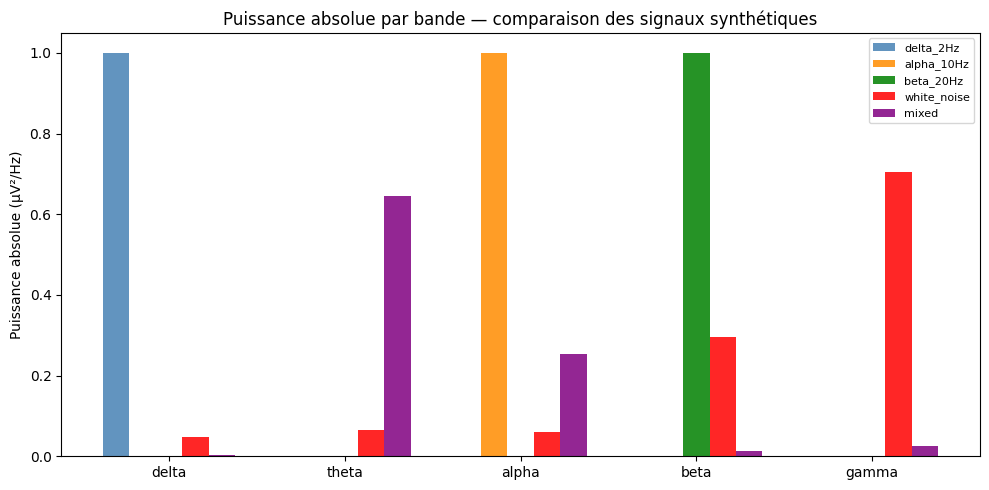

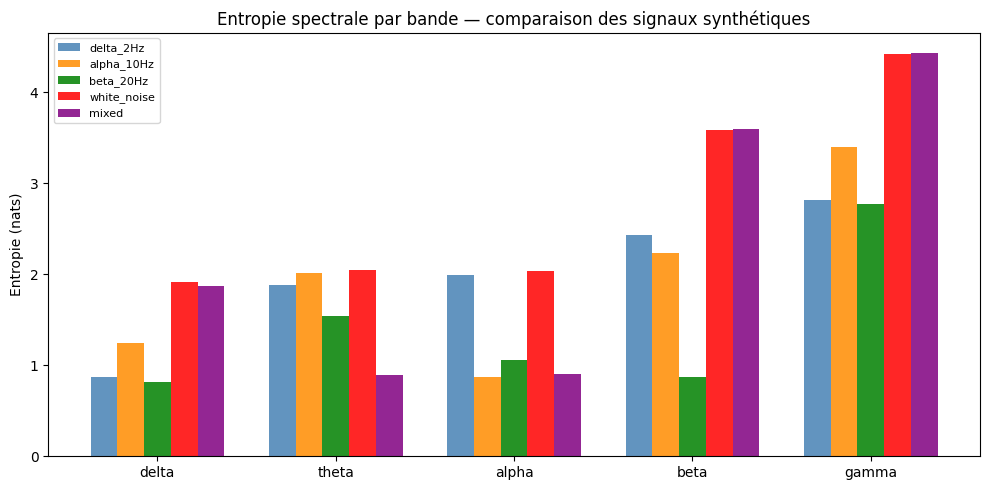


Features non linéaires et statistiques :
             hjorth_mobility  hjorth_complexity  lempel_ziv  higuchi_fd  raw_std
delta_2Hz             0.0491             1.0008      0.0354      0.0050   0.7071
alpha_10Hz            0.2448             1.0007      0.0531      0.1060   0.7071
beta_20Hz             0.4859             1.0006      0.0708      0.5097   0.7071
white_noise           1.4189             1.2207      1.0614      0.9994   0.9965
mixed                 0.4403             3.6457      0.3405      0.4288   0.6965

Interprétation :
  ✓ alpha_10Hz  : puissance alpha dominante, entropie alpha faible, LZ et FD bas (signal lisse)
  ✓ beta_20Hz   : puissance beta dominante
  ✓ white_noise : entropies élevées, LZ ≈ 1, Higuchi FD élevé, complexity Hjorth élevée
  ✓ mixed       : mélange theta+alpha → deux bandes actives, valeurs intermédiaires
  ✓ delta_2Hz   : puissance delta dominante, LZ bas, FD bas



In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Extraire les 40 features pour chaque signal synthétique ──────────────────
results = {}
for name, sig in synthetic_signals.items():
    results[name] = extract_eeg_features(sig, fs=FS)

df_results = pd.DataFrame(results).T   # lignes = signaux, colonnes = features
print(f"Shape du tableau de features : {df_results.shape}  (5 signaux × 40 features)")

# ── 1. Puissances absolues par bande ─────────────────────────────────────────
abs_cols = [f"{b}_abs" for b in EEG_BANDS]
df_abs   = df_results[abs_cols]
df_abs.columns = list(EEG_BANDS.keys())

fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(EEG_BANDS))
width = 0.15

colors = ["steelblue", "darkorange", "green", "red", "purple"]
for i, (name, row) in enumerate(df_abs.iterrows()):
    ax.bar(x_positions + i * width, row.values, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x_positions + width * 2)
ax.set_xticklabels(list(EEG_BANDS.keys()))
ax.set_title("Puissance absolue par bande — comparaison des signaux synthétiques")
ax.set_ylabel("Puissance absolue (µV²/Hz)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

# ── 2. Entropies spectrales par bande ─────────────────────────────────────────
ent_cols = [f"{b}_entropy" for b in EEG_BANDS]
df_ent   = df_results[ent_cols]
df_ent.columns = list(EEG_BANDS.keys())

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, row) in enumerate(df_ent.iterrows()):
    ax.bar(x_positions + i * width, row.values, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x_positions + width * 2)
ax.set_xticklabels(list(EEG_BANDS.keys()))
ax.set_title("Entropie spectrale par bande — comparaison des signaux synthétiques")
ax.set_ylabel("Entropie (nats)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── 3. Features non linéaires et statistiques ─────────────────────────────────
nonlinear_cols = ["hjorth_mobility", "hjorth_complexity", "lempel_ziv", "higuchi_fd", "raw_std"]
print("\nFeatures non linéaires et statistiques :")
print(df_results[nonlinear_cols].round(4).to_string())

print("""
Interprétation :
  ✓ alpha_10Hz  : puissance alpha dominante, entropie alpha faible, LZ et FD bas (signal lisse)
  ✓ beta_20Hz   : puissance beta dominante
  ✓ white_noise : entropies élevées, LZ ≈ 1, Higuchi FD élevé, complexity Hjorth élevée
  ✓ mixed       : mélange theta+alpha → deux bandes actives, valeurs intermédiaires
  ✓ delta_2Hz   : puissance delta dominante, LZ bas, FD bas
""")

## 12. Application aux signaux EEG du dataset CL-Drive

Après les tests pédagogiques, les mêmes fonctions doivent être appliquées aux signaux EEG prétraités.

### Hypothèse de structure des fichiers

On suppose que les fichiers EEG prétraités sont des fichiers CSV contenant :

- une colonne `Timestamp` ;
- une colonne par canal EEG, par exemple `AF7`, `AF8`, `TP9`, `TP10`.

Exemple de structure :

| Timestamp | AF7 | AF8 | TP9 | TP10 |
|---:|---:|---:|---:|---:|
| 0.000 | ... | ... | ... | ... |
| 0.004 | ... | ... | ... | ... |

### Algorithme d'extraction sur un fichier

1. lire le fichier CSV avec `pd.read_csv` ;
2. identifier les colonnes EEG ;
3. découper le signal en fenêtres de 10 secondes ;
4. pour chaque fenêtre :
   - extraire les 2560 échantillons ;
   - pour chaque canal, calculer les 40 features ;
   - stocker les métadonnées : sujet, fichier, fenêtre, temps début, temps fin, canal ;
5. construire un `DataFrame` ;
6. sauvegarder le résultat en CSV.

### Question

Pourquoi faut-il conserver les colonnes `sujet`, `scénario`, `fenêtre`, `canal`, `temps début` et `temps fin` avec les features ?

### Réponse

Ces métadonnées sont indispensables pour trois raisons :

1. **Association avec les labels** : les scores PAAS sont enregistrés toutes les 10 secondes dans un fichier séparé (Labels/). Pour relier chaque vecteur de features à son label, il faut connaître l'intervalle temporel `[temps début, temps fin]` de la fenêtre et l'identifier du scénario.

2. **Validation croisée LOSO** : la stratégie Leave-One-Subject-Out du papier nécessite de connaître l'`id_sujet` de chaque fenêtre pour construire correctement les folds (entraîner sur 20 sujets, tester sur le 21e).

3. **Diagnostic et débogage** : si un modèle se trompe systématiquement sur certaines fenêtres, les métadonnées permettent d'identifier si le problème vient d'un canal spécifique, d'un scénario particulier ou d'un sujet difficile à classer.

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path


def extract_features_from_eeg_df(df, participant_id, scenario,
                                   fs=FS, window_sec=WINDOW_SEC,
                                   eeg_cols=None, time_col="Timestamp"):
    """
    Extrait les features EEG fenêtre par fenêtre depuis un DataFrame CL-Drive.

    Paramètres
    ----------
    df             : DataFrame (colonnes Timestamp + canaux EEG)
    participant_id : identifiant du participant (ex. "1030")
    scenario       : numéro du scénario (ex. 1)
    fs             : fréquence d'échantillonnage
    window_sec     : durée d'une fenêtre en secondes (10 s dans CL-Drive)
    eeg_cols       : colonnes EEG à traiter (None = tout sauf Timestamp)

    Retourne
    --------
    DataFrame dont chaque ligne est une fenêtre × canal avec ses 40 features
    et ses métadonnées
    """
    window_samples = fs * window_sec

    if eeg_cols is None:
        eeg_cols = [c for c in df.columns if c != time_col]

    t_values = df[time_col].values if time_col in df.columns else np.arange(len(df)) / fs
    t_rel = t_values - t_values[0]  # temps relatif à partir de 0

    n_samples = len(df)
    n_windows = n_samples // window_samples  # fenêtres complètes uniquement

    rows = []

    for win_idx in range(n_windows):
        start = win_idx * window_samples
        end   = start + window_samples

        t_start = float(t_rel[start])
        t_end   = float(t_rel[end - 1])

        for col in eeg_cols:
            segment = df[col].values[start:end]

            # Vérification NaN : exclure les fenêtres avec données manquantes
            if np.isnan(segment).any():
                continue

            feats = extract_eeg_features(segment, fs=fs)

            # Ajouter les métadonnées en tête du dictionnaire
            row = {
                "participant_id": participant_id,
                "scenario"      : scenario,
                "window_idx"    : win_idx,
                "canal"         : col,
                "t_start_s"     : t_start,
                "t_end_s"       : t_end,
            }
            row.update(feats)
            rows.append(row)

    return pd.DataFrame(rows)


# ── Démonstration sur le fichier participant 1030, niveau 1 ───────────────────
from pathlib import Path

DATASET_ROOT = Path(r"c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive")
EEG_DIR      = DATASET_ROOT / "EEG"

# Charger le fichier filtré (créé en TD3)
filtered_path = EEG_DIR / "1030" / "filtered_eeg_data_level_1.csv"
df_filt = pd.read_csv(filtered_path)

print(f"Fichier chargé : {filtered_path.name}  (shape : {df_filt.shape})")
print(f"Fenêtres de {WINDOW_SEC} s → {len(df_filt) // WINDOW_SAMPLES} fenêtres complètes")

df_features = extract_features_from_eeg_df(df_filt, participant_id="1030", scenario=1)

print(f"\nShape du DataFrame de features : {df_features.shape}")
print(f"  → {df_features['window_idx'].nunique()} fenêtres × {df_features['canal'].nunique()} canaux")
print(f"  → {df_features.shape[1]} colonnes (6 métadonnées + 40 features)")
print(f"\nPremières lignes :")
print(df_features[["participant_id", "scenario", "window_idx", "canal", "t_start_s", "alpha_abs", "hjorth_mobility"]].head(8).to_string())

Fichier chargé : filtered_eeg_data_level_1.csv  (shape : (46594, 5))
Fenêtres de 10 s → 18 fenêtres complètes

Shape du DataFrame de features : (72, 46)
  → 18 fenêtres × 4 canaux
  → 46 colonnes (6 métadonnées + 40 features)

Premières lignes :
  participant_id  scenario  window_idx canal  t_start_s   alpha_abs  hjorth_mobility
0           1030         1           0   TP9        0.0  110.393663         0.298904
1           1030         1           0   AF7        0.0   27.381253         0.409372
2           1030         1           0   AF8        0.0   45.886711         0.394115
3           1030         1           0  TP10        0.0   94.984450         0.341012
4           1030         1           1   TP9       10.0  268.959553         0.259149
5           1030         1           1   AF7       10.0  128.563653         0.362681
6           1030         1           1   AF8       10.0  128.655260         0.422631
7           1030         1           1  TP10       10.0  296.628000       

## 13. Traitement par lot des fichiers EEG prétraités

Dans le projet, les fichiers prétraités peuvent être organisés par sujet.

Exemple :

```text
Data/
|----EEG/
    ├── Player_01/
    │   ├── filtered_scenario_1.csv
    │   ├── filtered_scenario_2.csv
    │   └── ...
    ├── Player_02/
    │   └── ...
|----EDA
|----ECG
|----Gaze
|----Labels
```

### Algorithme par lot

1. parcourir les dossiers sujets ;
2. sélectionner uniquement les fichiers `filtered_*.csv` ;
3. lire chaque fichier ;
4. extraire les features fenêtre par fenêtre ;
6. sauvegarder un fichier CSV de features par sujet.

### Remarque importante

Les labels PAAS ne se trouvent pas dans le même fichier que les signaux. Une étape d’association entre les features et les labels est donc nécessaire dans un second temps : il faut relier les scores de charge cognitive aux intervalles temporels correspondants.

In [12]:
from pathlib import Path
import pandas as pd


def batch_extract_eeg_features(eeg_dir, output_dir, fs=FS, window_sec=WINDOW_SEC,
                                eeg_cols=None, time_col="Timestamp",
                                participants=None):
    """
    Extrait les features EEG de tous les fichiers filtered_eeg_data_level_*.csv.

    Structure attendue
    ------------------
    eeg_dir/
      <participant_id>/
        filtered_eeg_data_level_1.csv
        filtered_eeg_data_level_2.csv
        ...

    Algorithme
    ----------
    1. Parcourir les dossiers participants
    2. Pour chaque fichier filtered_*.csv :
       a. Charger le CSV
       b. Extraire les features fenêtre par fenêtre
       c. Sauvegarder un fichier CSV de features par participant dans output_dir

    Retourne
    --------
    saved : liste des chemins des fichiers de features sauvegardés
    """
    eeg_dir    = Path(eeg_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    participant_dirs = sorted(d for d in eeg_dir.iterdir() if d.is_dir())
    if participants is not None:
        participant_dirs = [d for d in participant_dirs if d.name in participants]

    print(f"Dossier EEG    : {eeg_dir}")
    print(f"Sortie features: {output_dir}")
    print(f"Participants   : {[d.name for d in participant_dirs]}")
    print("─" * 70)

    saved = []

    for part_dir in participant_dirs:
        pid = part_dir.name
        filtered_files = sorted(part_dir.glob("filtered_eeg_data_level_*.csv"))

        all_rows = []

        for csv_path in filtered_files:
            # Extraire le numéro du scénario depuis le nom du fichier
            # "filtered_eeg_data_level_3.csv" → scénario = 3
            scenario = int(csv_path.stem.split("_")[-1])

            try:
                df_raw = pd.read_csv(csv_path)
            except Exception as e:
                print(f"[ERREUR]  {pid}/scénario {scenario} — {e}")
                continue

            df_feat = extract_features_from_eeg_df(
                df_raw, participant_id=pid, scenario=scenario,
                fs=fs, window_sec=window_sec,
                eeg_cols=eeg_cols, time_col=time_col
            )

            all_rows.append(df_feat)
            print(f"[OK]  {pid}/scénario {scenario} — {len(df_feat)} lignes")

        if all_rows:
            df_participant = pd.concat(all_rows, ignore_index=True)
            out_path = output_dir / f"features_{pid}.csv"
            df_participant.to_csv(out_path, index=False)
            saved.append(str(out_path))
            print(f"  → Sauvegardé : {out_path.name}  (shape : {df_participant.shape})")

    print("─" * 70)
    print(f"Résumé : {len(saved)} fichier(s) de features sauvegardé(s).")
    return saved


# ── Démonstration sur participant 1030 uniquement ─────────────────────────────
DATASET_ROOT = Path(r"c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive")
EEG_DIR      = DATASET_ROOT / "EEG"
FEATURES_DIR = DATASET_ROOT / "EEG_Features"

saved_files = batch_extract_eeg_features(
    EEG_DIR,
    FEATURES_DIR,
    participants=["1030"],   # retirer cette ligne pour traiter les 21 participants
)

# Vérification
if saved_files:
    df_check = pd.read_csv(saved_files[0])
    print(f"\nVérification — {saved_files[0]} :")
    print(f"  Shape   : {df_check.shape}")
    print(f"  Canaux  : {df_check['canal'].unique().tolist()}")
    print(f"  Scénar  : {sorted(df_check['scenario'].unique().tolist())}")
    print(f"  Fenêtres: {df_check['window_idx'].nunique()} uniques par scénario × canal")

Dossier EEG    : c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive\EEG
Sortie features: c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive\EEG_Features
Participants   : ['1030']
──────────────────────────────────────────────────────────────────────
[OK]  1030/scénario 1 — 72 lignes
[OK]  1030/scénario 2 — 72 lignes
[OK]  1030/scénario 3 — 72 lignes
[OK]  1030/scénario 5 — 72 lignes
[OK]  1030/scénario 6 — 72 lignes
[OK]  1030/scénario 7 — 64 lignes
[OK]  1030/scénario 8 — 72 lignes
[OK]  1030/scénario 9 — 72 lignes
  → Sauvegardé : features_1030.csv  (shape : (568, 46))
──────────────────────────────────────────────────────────────────────
Résumé : 1 fichier(s) de features sauvegardé(s).

Vérification — c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive\EEG_Features\features_1030.csv :
  Shape   : (568, 46)
  Canaux  : ['TP9', 'AF7', 'AF8', 'TP10']
  Scénar  : [1, 2, 3, 5, 6, 7, 8, 9]
  Fenêtres: 18 uniques par scénario × canal


## 14. Vérifications qualité des features

Avant de passer à la classification, il faut vérifier la qualité de la matrice de features.

### Vérifications recommandées

1. nombre de lignes cohérent avec le nombre de fenêtres et de canaux ;
2. absence de valeurs manquantes ;
3. absence de valeurs infinies ;
4. ordre de grandeur plausible ;
5. nombre de features égal à 40 par canal ;
6. conservation des métadonnées utiles ;
7. possibilité d'associer ensuite chaque fenêtre à un label.

### Questions et réponses

**1. Pourquoi des valeurs `NaN` peuvent-elles apparaître dans les features ?**

Des NaN peuvent surgir dans plusieurs situations :
- **Bande vide** : si la résolution fréquentielle (nperseg) est trop grossière, aucun bin de Welch ne tombe dans une bande étroite (ex. delta 0.5–4 Hz avec un signal de 1 s). La bande_psd est vide et `mean([]) = NaN` sans protection.
- **Signal constant** : `Var(x) = 0` → `sqrt(Var(Δx)/0) = NaN` dans Hjorth. Sans le test `if var_x == 0`, mobility serait NaN.
- **log(0)** : si `L(k) = 0` dans Higuchi ou si `band_psd.sum() = 0` dans l'entropie, sans protection le log retourne `-inf` ou `NaN`.

**2. Pourquoi des valeurs infinies peuvent-elles apparaître ?**

Des valeurs infinies apparaissent principalement :
- `log(0) = -∞` : dans `higuchi_fd` si une sous-séquence a une longueur nulle, ou dans `compute_spectral_entropy_bands` si la PSD d'une bande est nulle — sans `np.maximum(L, 1e-10)`.
- `1 / 0` dans Hjorth : si `var_x = 0` sans vérification préalable.

Dans les deux fonctions implémentées, ces cas sont protégés. Mais un pipeline différent (ex. copier-coller d'une autre source) pourrait ne pas les gérer.

**3. Que doit-on faire si un segment contient trop de valeurs manquantes ?**

Exclure le segment entier, conformément à la méthode du papier CL-Drive (section IV.A) : *"segments with missing data are excluded"*. Il ne faut surtout pas interpoler (les features calculées sur un signal interpolé reflèteraient les propriétés de l'interpolation, pas l'état cognitif du conducteur). La perte de quelques fenêtres de 10 s est acceptable face au risque d'introduire des données synthétiques dans l'ensemble d'entraînement.

**4. Pourquoi faut-il éviter de normaliser les features avant la séparation train/test ?**

Si on normalise sur l'ensemble complet (train + test) avant de séparer, les **statistiques du test set** (moyenne, écart-type) influencent la transformation appliquée au train set — c'est une **fuite de données** (*data leakage*). Le modèle a indirectement "vu" le test set pendant l'entraînement, ce qui donne une estimation trop optimiste des performances.

La bonne pratique est :
1. Calculer les paramètres de normalisation **uniquement sur le train set** (`scaler.fit(X_train)`).
2. Appliquer ces paramètres au test set sans les recalculer (`scaler.transform(X_test)`).

Cette règle est d'autant plus importante en validation LOSO : les paramètres de normalisation doivent être recalculés à chaque fold en excluant le sujet de test.

In [13]:
import numpy as np
import pandas as pd


def check_feature_quality(df_features, n_features_expected=40,
                           feature_start_col="delta_abs"):
    """
    Vérifie la qualité d'un DataFrame de features EEG.

    Vérifications
    -------------
    1. Nombre de colonnes de features = 40 (ou n_features_expected)
    2. Absence de NaN dans les colonnes de features
    3. Absence de valeurs infinies
    4. Ordre de grandeur plausible (pas de valeur > 1e10 ou < -1e10)
    5. Aucune colonne de features avec variance nulle (feature constante)

    Retourne
    --------
    report : dict résumant les problèmes trouvés
    ok     : bool — True si tout est correct
    """
    # Identifier les colonnes de features (après les métadonnées)
    meta_cols  = ["participant_id", "scenario", "window_idx", "canal", "t_start_s", "t_end_s"]
    feat_cols  = [c for c in df_features.columns if c not in meta_cols]
    df_feat    = df_features[feat_cols]

    report = {}
    issues = []

    # ── 1. Nombre de features ─────────────────────────────────────────────────
    n_feat = len(feat_cols)
    if n_feat != n_features_expected:
        issues.append(f"Nombre de features : {n_feat} (attendu : {n_features_expected})")
    report["n_features"] = n_feat

    # ── 2. NaN ────────────────────────────────────────────────────────────────
    nan_counts = df_feat.isna().sum()
    n_nan_cols = int((nan_counts > 0).sum())
    if n_nan_cols > 0:
        issues.append(f"NaN dans {n_nan_cols} colonnes : {nan_counts[nan_counts > 0].to_dict()}")
    report["n_nan_cols"] = n_nan_cols
    report["n_nan_total"] = int(nan_counts.sum())

    # ── 3. Valeurs infinies ───────────────────────────────────────────────────
    inf_mask  = np.isinf(df_feat.values)
    n_inf     = int(inf_mask.sum())
    if n_inf > 0:
        inf_cols = [feat_cols[i] for i in np.where(inf_mask.any(axis=0))[0]]
        issues.append(f"Valeurs infinies : {n_inf} dans {list(inf_cols)}")
    report["n_inf"] = n_inf

    # ── 4. Ordre de grandeur ──────────────────────────────────────────────────
    abs_max = float(df_feat.abs().max().max())
    if abs_max > 1e10:
        issues.append(f"Valeur absolue max très élevée : {abs_max:.2e}")
    report["abs_max"] = abs_max

    # ── 5. Colonnes constantes (variance nulle) ───────────────────────────────
    zero_var_cols = [c for c in feat_cols if df_feat[c].std() == 0]
    if zero_var_cols:
        issues.append(f"Colonnes constantes (variance nulle) : {zero_var_cols}")
    report["zero_var_cols"] = zero_var_cols

    # ── Résumé ────────────────────────────────────────────────────────────────
    ok = len(issues) == 0

    print(f"=== Rapport qualité des features ===\n")
    print(f"  Lignes (fenêtres × canaux) : {len(df_features)}")
    print(f"  Colonnes de features       : {n_feat}")
    print(f"  NaN                        : {report['n_nan_total']}")
    print(f"  Infinis                    : {n_inf}")
    print(f"  Valeur absolue max         : {abs_max:.4e}")
    print(f"  Colonnes constantes        : {zero_var_cols if zero_var_cols else 'aucune'}")
    print(f"\n  Problèmes : {'aucun ✓' if not issues else ''}")
    for issue in issues:
        print(f"    ✗ {issue}")
    print(f"\n  Décision : {'✓ DataFrame prêt pour la classification' if ok else '✗ Corriger les problèmes avant de classifier'}")

    return report, ok


# ── Application au DataFrame de features du participant 1030 ──────────────────
from pathlib import Path

DATASET_ROOT = Path(r"c:\Users\pault\OneDrive\Documents\neurone\Neuronanale\CL-Drive")
features_path = DATASET_ROOT / "EEG_Features" / "features_1030.csv"
df_feats = pd.read_csv(features_path)

report, ok = check_feature_quality(df_feats)

# ── Test avec un problème injecté ─────────────────────────────────────────────
print("\n=== Test avec NaN injecté ===\n")
df_broken = df_feats.copy()
df_broken.loc[0, "alpha_abs"] = np.nan
df_broken.loc[5, "higuchi_fd"] = np.inf
report2, ok2 = check_feature_quality(df_broken)

=== Rapport qualité des features ===

  Lignes (fenêtres × canaux) : 568
  Colonnes de features       : 40
  NaN                        : 0
  Infinis                    : 0
  Valeur absolue max         : 4.9024e+04
  Colonnes constantes        : aucune

  Problèmes : aucun ✓

  Décision : ✓ DataFrame prêt pour la classification

=== Test avec NaN injecté ===

=== Rapport qualité des features ===

  Lignes (fenêtres × canaux) : 568
  Colonnes de features       : 40
  NaN                        : 1
  Infinis                    : 1
  Valeur absolue max         : inf
  Colonnes constantes        : aucune

  Problèmes : 
    ✗ NaN dans 1 colonnes : {'alpha_abs': 1}
    ✗ Valeurs infinies : 1 dans ['higuchi_fd']
    ✗ Valeur absolue max très élevée : inf

  Décision : ✗ Corriger les problèmes avant de classifier
